In [626]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nba_api.stats.endpoints.drafthistory import DraftHistory
import requests

In [627]:
def get_draft_data(year):
    """Fetch WNBA draft data for a given year using the nba_api."""
    draft_data = DraftHistory(season_year_nullable=year, league_id='10')
    draft_df = draft_data.get_data_frames()[0]
    return draft_df

In [628]:
def get_team_stats(compid):
    team_stats_url = f'https://api.cbbanalytics.com/api/gs/team-agg-stats/competition/{compid}/division/1/scope/season/'
    team_stats_df = pd.DataFrame(requests.get(team_stats_url).json())
    team_stats_df['fullName'] = team_stats_df['teamMarket'] + ' ' + team_stats_df['teamName'] + ' ' + 'Women\'s'
    return team_stats_df

In [629]:
draft_2025_df = get_draft_data(2025)
draft_2025_df.head()

,PERSON_ID,PLAYER_NAME,SEASON,ROUND_NUMBER,ROUND_PICK,OVERALL_PICK,DRAFT_TYPE,TEAM_ID,TEAM_CITY,TEAM_NAME,TEAM_ABBREVIATION,ORGANIZATION,ORGANIZATION_TYPE,PLAYER_PROFILE_FLAG
0,1642784,Paige Bueckers,2025,1,1,1,Draft,1611661321,Dallas,Wings,DAL,,,1
1,1642798,Dominique Malonga,2025,1,2,2,Draft,1611661328,Seattle,Storm,SEA,,,1
2,1642785,Sonia Citron,2025,1,3,3,Draft,1611661322,Washington,Mystics,WAS,,,1
3,1642792,Kiki Iriafen,2025,1,4,4,Draft,1611661322,Washington,Mystics,WAS,,,1
4,1642794,Juste Jocyte,2025,1,5,5,Draft,1611661331,Golden State,Valkyries,GSV,,,1


In [630]:
drafted_players_2025 = draft_2025_df['PLAYER_NAME'].unique()

In [631]:
player_stats_2025 = pd.read_csv('./data/Copy of WBB Data - ncaa_2425.csv')
player_stats_2025 = player_stats_2025[player_stats_2025['Class'] == 'SR']
player_stats_2025['Drafted'] = player_stats_2025['Player'].apply(lambda x: 1 if x in drafted_players_2025 else 0)

In [632]:
player_stats_2025.head()

,Team,Player,#,Class,Height,Summary,G,GS,MP,FG,...,OWS,DWS,WS,WS/40,OBPM,DBPM,BPM,Conference,Season,Drafted
0,Youngstown State Penguins Women's,Jewel Watkins,10,SR,5-11,"15.3 Pts, 3.4 Reb, 1.5 Ast",31.0,31.0,1006.0,160.0,...,1.2,1.2,2.4,0.097,-1.0,-1.9,-2.9,Horizon WBB,2024-2025,0
1,Youngstown State Penguins Women's,Malia Magestro,2,SR,5-9,"11.1 Pts, 2.5 Reb, 2.3 Ast",27.0,26.0,870.0,93.0,...,1.4,0.8,2.2,0.102,-1.3,-1.7,-3.0,Horizon WBB,2024-2025,0
3,Youngstown State Penguins Women's,Faith Burch,22,SR,6-1,"6.8 Pts, 5.8 Reb, 0.8 Ast",26.0,22.0,550.0,68.0,...,-0.1,0.9,0.8,0.058,-4.5,-1.4,-5.9,Horizon WBB,2024-2025,0
5,Youngstown State Penguins Women's,Haley Thierry,23,SR,5-8,"4.9 Pts, 5.1 Reb, 1.7 Ast",29.0,6.0,591.0,48.0,...,0.9,1.1,2.0,0.138,-0.8,1.0,0.1,Horizon WBB,2024-2025,0
15,Yale Bulldogs Women's,Mackenzie Egger,24,SR,5-11,"15.3 Pts, 9.4 Reb, 1.5 Ast",26.0,26.0,891.0,156.0,...,1.3,0.8,2.1,0.093,1.9,-1.0,0.8,Ivy WBB,2024-2025,0


In [633]:
team_stats_df_2025 = get_team_stats(38529)

In [634]:
from difflib import get_close_matches

api_names = team_stats_df_2025['fullName'].tolist()

def best_match(name, api_names=api_names):
    if name in api_names:                                      # exact first
        return name
    m = get_close_matches(name, api_names, n=1, cutoff=0.6)   # fuzzy fallback
    return m[0] if m else None

team_map = {t: best_match(t) for t in player_stats_2025['Team'].unique()}
player_stats_2025['_team_key'] = player_stats_2025['Team'].map(team_map)

unmatched = [t for t, v in team_map.items() if v is None]
print(f"Matched: {player_stats_2025['_team_key'].notna().sum():,} / {len(player_stats_2025):,} rows")
print(f"Unmatched teams ({len(unmatched)}): {unmatched[:10]}")


Matched: 1,758 / 1,758 rows
Unmatched teams (0): []


In [635]:
# team_rating_cols = ['fullName','sos','netRanking','netRtgAdjGap','netRtgAdj','ortgAdjGap','ortgAdj','drtgAdjGap','drtgAdj']
team_rating_cols = ['fullName','sos']
# isOffense==True gives one row per team (vs the defensive split row) — use it just for dedup
team_stats_dedup = (team_stats_df_2025[team_stats_df_2025['isOffense'] == True][team_rating_cols]
                    .drop_duplicates(subset='fullName'))

player_stats_2025 = pd.merge(
    player_stats_2025,
    team_stats_dedup,
    left_on='_team_key',
    right_on='fullName',
    how='left'
).drop(columns=['_team_key', 'fullName'])

print(f"Rows: {len(player_stats_2025)}")
print(f"Team ratings filled: {player_stats_2025['sos'].notna().sum():,} rows")
# player_stats_2025[['Team','netRtgAdj','ortgAdj','drtgAdj','sos']].dropna().head()


Rows: 1758
Team ratings filled: 1,758 rows


In [636]:
def feature_engineering(dframe):
    df = dframe.copy()
    # ── 1. Physical / Identity ────────────────────────────────────────────────────
    def height_to_inches(h):
        try:
            ft, inch = str(h).split('-')
            return int(ft) * 12 + int(inch)
        except Exception:
            return np.nan

    df['height_in'] = df['Height'].apply(height_to_inches)

    class_map = {'FR': 1, 'So': 2, 'SO': 2, 'JR': 3, 'Jr': 3, 'SR': 4, 'Sr': 4, 'GR': 5, 'Gr': 5}
    df['class_ord'] = df['Class'].map(class_map).fillna(2)

    # ── 2. Per-game rates ─────────────────────────────────────────────────────────
    per_game_cols = {'PTS': 'pts_pg', 'TRB': 'trb_pg', 'AST': 'ast_pg',
                    'STL': 'stl_pg', 'BLK': 'blk_pg', 'TOV': 'tov_pg',
                    'FGA': 'fga_pg', 'FTA': 'fta_pg', 'MP':  'mp_pg'}
    for raw, feat in per_game_cols.items():
        df[feat] = df[raw] / df['G'].replace(0, np.nan)

    # ── 3. Per-40-minute rates (controls for PT differences) ─────────────────────
    mp_safe = df['MP'].replace(0, np.nan)
    per40_cols = {'PTS': 'pts_p40', 'TRB': 'trb_p40', 'AST': 'ast_p40',
                'STL': 'stl_p40', 'BLK': 'blk_p40', 'TOV': 'tov_p40',
                'ORB': 'orb_p40', 'DRB': 'drb_p40'}
    for raw, feat in per40_cols.items():
        df[feat] = df[raw] / mp_safe * 40

    # ── 4. Efficiency / ratio features ───────────────────────────────────────────
    df['ast_tov_ratio']     = df['AST'] / df['TOV'].replace(0, np.nan)
    df['stl_blk_pg']        = df['stl_pg'] + df['blk_pg']          # defensive disruption
    df['stl_blk_tov_ratio'] = df['stl_blk_pg'] / df['tov_pg'].replace(0, np.nan)
    df['pts_per_fga']       = df['PTS'] / df['FGA'].replace(0, np.nan)  # raw scoring efficiency
    df['ft_rate']           = df['FTA'] / df['FGA'].replace(0, np.nan)  # drawing contact
    df['non3_fg_pct']       = df['2P'] / df['2PA'].replace(0, np.nan)   # interior efficiency
    df['rim_rate']          = df['2PA'] / df['FGA'].replace(0, np.nan)  # shot profile (inside vs perimeter)
    df['games_started_pct'] = df['GS'] / df['G'].replace(0, np.nan)     # starter vs bench role

    # ── 5. Composite impact scores ────────────────────────────────────────────────
    # Offensive impact: PER + OBPM, scaled by usage
    df['off_composite']  = df['PER'] + df['OBPM'] + df['USG%'] / 10
    # Defensive impact: DBPM + steal/block rates
    df['def_composite']  = df['DBPM'] + df['STL%'] + df['BLK%']
    # Two-way BPM gap (positive = better offensively, negative = defensive specialist)
    df['bpm_gap']        = df['OBPM'] - df['DBPM']
    # Win-share efficiency (quality of contribution relative to minutes)
    df['ws_per_game']    = df['WS'] / df['G'].replace(0, np.nan)
    # Versatility: scoring + rebounding + playmaking per 40
    df['versatility']    = df['pts_p40'] + df['trb_p40'] + df['ast_p40']
    # Pure scoring load: how much of team usage they handle vs how efficiently
    df['scoring_load']   = df['USG%'] * df['TS%']
    # Production composite (mimics scouts' box-score checklist)
    df['prod_composite'] = (
        df['pts_pg'] * 1.0 +
        df['trb_pg'] * 1.2 +
        df['ast_pg'] * 1.5 +
        df['stl_pg'] * 2.0 +
        df['blk_pg'] * 2.0 -
        df['tov_pg'] * 1.5
    )

    # ── 6. Conference strength tier ───────────────────────────────────────────────
    power_conf  = {'ACC WBB', 'Big Ten WBB', 'SEC WBB', 'Big 12 WBB', 'Pac-12 WBB'}
    high_conf   = {'Big East WBB', 'American Athletic WBB', 'Mountain West WBB', 'Atlantic 10 WBB'}
    mid_conf    = {'Missouri Valley WBB', 'WAC WBB', 'Sun Belt WBB', 'Conference USA WBB', 'WCC WBB'}

    def conf_tier(c):
        if c in power_conf: return 3
        if c in high_conf:  return 2
        if c in mid_conf:   return 1
        return 0

    df['conf_tier'] = df['Conference'].apply(conf_tier)
    # Conference-adjusted BPM: reward good BPM in stronger conferences
    df['bpm_sos_adj'] = df['BPM'] * (1 + df['sos'])

    # ── 7. Percentile ranks (within full player pool) ────────────────────────────
    pct_cols = ['BPM', 'WS', 'WS/40', 'PER', 'TS%', 'prod_composite',
                'versatility', 'off_composite', 'def_composite', 'bpm_sos_adj']
    for col in pct_cols:
        df[f'{col}_pct'] = df[col].rank(pct=True)
    return df

In [637]:
df = feature_engineering(player_stats_2025)

# ── Summary ───────────────────────────────────────────────────────────────────
new_feats = [c for c in df.columns if c not in player_stats_2025.columns]
print(f"Engineered {len(new_feats)} new features:")
print(new_feats)
df[new_feats + ['Drafted']].describe()


Engineered 46 new features:
['height_in', 'class_ord', 'pts_pg', 'trb_pg', 'ast_pg', 'stl_pg', 'blk_pg', 'tov_pg', 'fga_pg', 'fta_pg', 'mp_pg', 'pts_p40', 'trb_p40', 'ast_p40', 'stl_p40', 'blk_p40', 'tov_p40', 'orb_p40', 'drb_p40', 'ast_tov_ratio', 'stl_blk_pg', 'stl_blk_tov_ratio', 'pts_per_fga', 'ft_rate', 'non3_fg_pct', 'rim_rate', 'games_started_pct', 'off_composite', 'def_composite', 'bpm_gap', 'ws_per_game', 'versatility', 'scoring_load', 'prod_composite', 'conf_tier', 'bpm_sos_adj', 'BPM_pct', 'WS_pct', 'WS/40_pct', 'PER_pct', 'TS%_pct', 'prod_composite_pct', 'versatility_pct', 'off_composite_pct', 'def_composite_pct', 'bpm_sos_adj_pct']


,height_in,class_ord,pts_pg,trb_pg,ast_pg,stl_pg,blk_pg,tov_pg,fga_pg,fta_pg,...,WS_pct,WS/40_pct,PER_pct,TS%_pct,prod_composite_pct,versatility_pct,off_composite_pct,def_composite_pct,bpm_sos_adj_pct,Drafted
count,1757.000000,1758.0,1571.000000,1571.000000,1571.000000,1571.000000,1571.000000,1571.000000,1571.000000,1571.000000,...,1571.000000,1570.000000,1570.000000,1563.000000,1571.000000,1570.000000,1568.000000,1568.000000,1568.000000,1758.000000
mean,70.656801,4.0,7.279117,3.572404,1.507030,0.882286,0.353452,1.606206,6.397336,1.795530,...,0.500318,0.500318,0.500318,0.500320,0.500318,0.500318,0.500319,0.500319,0.500319,0.018771
std,3.205033,0.0,4.701390,2.205265,1.209687,0.601059,0.430933,0.883765,3.827513,1.384490,...,0.288669,0.288764,0.288763,0.288764,0.288767,0.288767,0.288767,0.288762,0.288767,0.135755
min,61.000000,4.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000637,0.000637,0.000637,0.003839,0.000955,0.003185,0.000638,0.000638,0.000638,0.000000
25%,68.000000,4.0,3.478261,1.965476,0.606061,0.444444,0.081667,0.953261,3.311422,0.700000,...,0.249204,0.250000,0.248726,0.250480,0.250477,0.250637,0.250478,0.253109,0.250478,0.000000
50%,71.000000,4.0,6.722222,3.200000,1.225806,0.794872,0.206897,1.533333,6.045455,1.518519,...,0.497772,0.499363,0.500955,0.500000,0.500318,0.500318,0.500319,0.499043,0.500319,0.000000
75%,73.000000,4.0,10.369318,4.766667,2.063508,1.208711,0.454545,2.176471,8.945195,2.559028,...,0.746022,0.750478,0.748089,0.751759,0.750159,0.750398,0.750159,0.747768,0.750159,0.000000
max,80.000000,4.0,24.375000,13.472222,7.277778,4.058824,3.657143,4.600000,18.576923,8.343750,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [638]:
df = df[(df['mp_pg'] >= df['mp_pg'].mean()) & (df['G'] >= df['G'].mean())]

In [639]:

drop_raw   = ['FG','FGA','FT','FTA','3P','3PA','2P','2PA','ORB','DRB','TRB',
              'AST','STL','BLK','TOV','PF','PTS','MP','PProd','#']

In [640]:
feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c != 'Drafted' and c not in drop_raw]

In [641]:
final_feature_corr = df[feature_cols + ['Drafted']].corr()['Drafted'].abs().sort_values(ascending=False).reset_index()
final_feature_corr['abs'] = final_feature_corr['Drafted'].abs()
final_feature_corr.head(20)

,index,Drafted,abs
0,Drafted,1.000000,1.000000
1,bpm_sos_adj,0.414999,0.414999
2,BPM,0.402560,0.402560
3,OBPM,0.367022,0.367022
4,DBPM,0.344464,0.344464
5,WS,0.343781,0.343781
6,sos,0.334727,0.334727
7,OWS,0.332709,0.332709
8,conf_tier,0.328562,0.328562
9,ws_per_game,0.325802,0.325802


In [642]:
final_feature_cols = final_feature_corr[final_feature_corr['abs'] > 0.05]['index'].tolist()
print(f"Selected {len(final_feature_cols)} features with |corr| > 0.05")
final_feature_cols.remove('Drafted')
print(final_feature_cols)

Selected 64 features with |corr| > 0.05
['bpm_sos_adj', 'BPM', 'OBPM', 'DBPM', 'WS', 'sos', 'OWS', 'conf_tier', 'ws_per_game', 'off_composite', 'WS/40', 'bpm_sos_adj_pct', 'BPM_pct', 'PER', 'prod_composite', 'def_composite', 'WS/40_pct', 'off_composite_pct', 'pts_pg', 'def_composite_pct', 'WS_pct', 'versatility', 'pts_p40', 'DWS', 'PER_pct', 'G', 'prod_composite_pct', 'fga_pg', 'scoring_load', 'versatility_pct', 'FG%', 'TS%_pct', 'TS%', 'eFG%', 'GS', 'non3_fg_pct', '2P%', 'ast_pg', 'bpm_gap', 'stl_blk_pg', 'ast_tov_ratio', 'pts_per_fga', 'ast_p40', 'USG%', 'TOV%', 'blk_pg', 'stl_blk_tov_ratio', 'height_in', 'mp_pg', 'games_started_pct', 'blk_p40', 'stl_pg', 'fta_pg', 'AST%', 'trb_pg', 'BLK%', '3P%', 'stl_p40', '3PAr', 'rim_rate', 'drb_p40', 'FT%', 'trb_p40']


In [643]:
from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_val_predict, RandomizedSearchCV, LeaveOneOut)
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from scipy.stats import randint, loguniform, uniform
import scipy.stats


X = df[final_feature_cols]
y = df['Drafted']

imputer = SimpleImputer(strategy='median')
X_imp   = pd.DataFrame(imputer.fit_transform(X), columns=final_feature_cols, index=X.index)

X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.2, random_state=42, stratify=y
)

neg, pos = (y_train == 0).sum(), y_train.sum()
spw = neg / pos
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"All features: {len(final_feature_cols)}")
print(f"Train — total: {len(y_train):,}  drafted: {pos}  not drafted: {neg}  imbalance: {neg/pos:.0f}:1")
print(f"Test  — total: {len(y_test):,}   drafted: {y_test.sum()}  not drafted: {(y_test==0).sum()}")

All features: 63
Train — total: 602  drafted: 23  not drafted: 579  imbalance: 25:1
Test  — total: 151   drafted: 6  not drafted: 145


In [644]:
# Helper function for model training and evaluation
from sklearn.metrics import roc_auc_score, average_precision_score

def evaluate_model(clf, X_train, y_train, X_test, y_test, name=None):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1] if hasattr(clf, 'predict_proba') else y_pred
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    print(f"{name or clf.__class__.__name__}: ROC AUC = {roc_auc:.3f}, PR AUC = {pr_auc:.3f}")
    return {'name': name or clf.__class__.__name__, 'roc_auc': roc_auc, 'pr_auc': pr_auc}

In [645]:
# XGBoost Classifier
xgb_clf = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=spw,   # handles 25:1 imbalance
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
)
xgb_results = evaluate_model(xgb_clf, X_train, y_train, X_test, y_test, name='XGBoost')

XGBoost: ROC AUC = 0.982, PR AUC = 0.693


In [646]:
# LightGBM Classifier
lgbm_clf = LGBMClassifier(
    random_state=42,
    scale_pos_weight=spw,   # handles 25:1 imbalance
    min_child_samples=5,    # default 20 is too high with only 23 positives
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    verbose=-1,
)
lgbm_results = evaluate_model(lgbm_clf, X_train, y_train, X_test, y_test, name='LightGBM')

LightGBM: ROC AUC = 0.976, PR AUC = 0.611


In [647]:
# Random Forest Classifier
rf_clf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',  # handles 25:1 imbalance
    n_estimators=500,
    max_depth=6,
    min_samples_leaf=2,
)
rf_results = evaluate_model(rf_clf, X_train, y_train, X_test, y_test, name='Random Forest')

Random Forest: ROC AUC = 0.976, PR AUC = 0.595


,name,roc_auc,pr_auc
0,XGBoost,0.981609,0.692995
1,LightGBM,0.975862,0.611442
2,Random Forest,0.975862,0.595238


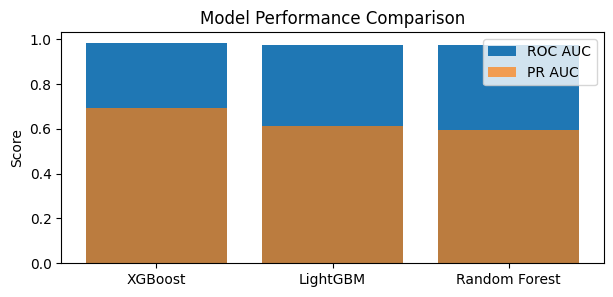

In [648]:
# Compare and summarize results
results = [xgb_results, lgbm_results, rf_results]
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('pr_auc', ascending=False)
display(results_df)

plt.figure(figsize=(7,3))
plt.bar(results_df['name'], results_df['roc_auc'], label='ROC AUC')
plt.bar(results_df['name'], results_df['pr_auc'], alpha=0.7, label='PR AUC')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.legend()
plt.show()

In [649]:
# Full pipeline: fit on all data, predict draft probabilities for all players
# Choose best model (highest PR AUC)
best_model_name = results_df.iloc[0]['name']
if best_model_name == 'XGBoost':
    best_clf = XGBClassifier(
        eval_metric='logloss', random_state=42, scale_pos_weight=spw,
        n_estimators=500, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
    )
elif best_model_name == 'LightGBM':
    best_clf = LGBMClassifier(
        random_state=42, scale_pos_weight=spw, min_child_samples=5,
        n_estimators=500, learning_rate=0.05, num_leaves=31,
        subsample=0.8, colsample_bytree=0.8, verbose=-1,
    )
else:
    best_clf = RandomForestClassifier(
        random_state=42, class_weight='balanced', n_estimators=500,
        max_depth=6, min_samples_leaf=2,
    )
print(f"Best model: {best_model_name}")

Best model: XGBoost


In [650]:
player_stats_2026 = pd.read_csv('./data/Copy of WBB Data - ncaa2526.csv')
player_stats_2026 = player_stats_2026[player_stats_2026['Class'] == 'SR']


In [651]:
player_stats_2026.head()

,Team,Player,#,Class,Pos,Height,Summary,G,GS,MP,...,USG%,OWS,DWS,WS,WS/40,OBPM,DBPM,BPM,Conference,Season
0,Youngstown State Penguins Women's,Casey Santoro,14.0,SR,G,5-4,"11.8 Pts, 5.5 Reb, 3.4 Ast",35.0,35.0,1263.0,...,19.7,2.7,2.3,5.0,0.158,0.3,0.0,0.3,Horizon WBB,2025-2026
15,Yale Bulldogs Women's,Kiley Capstraw,21.0,SR,G,5-10,"8.7 Pts, 6.5 Reb, 3.9 Ast",25.0,25.0,879.0,...,19.3,0.0,0.8,0.8,0.036,-2.9,-0.7,-3.6,Ivy WBB,2025-2026
30,Xavier Musketeers Women's,Savannah White,2.0,SR,F,6-2,"7.0 Pts, 7.3 Reb, 2.4 Ast",29.0,29.0,874.0,...,16.5,0.6,1.3,1.9,0.085,-0.1,3.2,3.0,Big East WBB,2025-2026
37,Xavier Musketeers Women's,Mya Moore,44.0,SR,F,6-0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Big East WBB,2025-2026
40,Wyoming Cowgirls Women's,Malene Pedersen,12.0,SR,G,5-11,"17.2 Pts, 4.0 Reb, 2.1 Ast",29.0,29.0,964.0,...,28.8,3.1,0.7,3.8,0.158,5.2,-1.9,3.4,MWC WBB,2025-2026


In [652]:
team_stats_df_2026 = get_team_stats(41098)

In [653]:
api_names = team_stats_df_2026['fullName'].tolist()

team_map = {t: best_match(t) for t in player_stats_2026['Team'].unique()}
player_stats_2026['_team_key'] = player_stats_2026['Team'].map(team_map)

unmatched = [t for t, v in team_map.items() if v is None]
print(f"Matched: {player_stats_2026['_team_key'].notna().sum():,} / {len(player_stats_2026):,} rows")
print(f"Unmatched teams ({len(unmatched)}): {unmatched[:10]}")


Matched: 1,412 / 1,412 rows
Unmatched teams (0): []


In [654]:
team_rating_cols = ['fullName','sos','netRanking','netRtgAdjGap','netRtgAdj','ortgAdjGap','ortgAdj','drtgAdjGap','drtgAdj']

# isOffense==True gives one row per team (vs the defensive split row) — use it just for dedup
team_stats_dedup = (team_stats_df_2026[team_stats_df_2026['isOffense'] == True][team_rating_cols]
                    .drop_duplicates(subset='fullName'))

player_stats_2026 = pd.merge(
    player_stats_2026,
    team_stats_dedup,
    left_on='_team_key',
    right_on='fullName',
    how='left'
).drop(columns=['_team_key', 'fullName'])

print(f"Rows: {len(player_stats_2026)}")
print(f"Team ratings filled: {player_stats_2026['netRtgAdj'].notna().sum():,} rows")
# player_stats_2026[['Team','netRtgAdj','ortgAdj','drtgAdj','sos']].dropna().head()


Rows: 1412
Team ratings filled: 1,407 rows


In [655]:
df2 = feature_engineering(player_stats_2026)
# ── Summary ───────────────────────────────────────────────────────────────────
new_feats = [c for c in df2.columns if c not in player_stats_2026.columns]
print(f"Engineered {len(new_feats)} new features:")
print(new_feats)
df2[new_feats].describe()


Engineered 46 new features:
['height_in', 'class_ord', 'pts_pg', 'trb_pg', 'ast_pg', 'stl_pg', 'blk_pg', 'tov_pg', 'fga_pg', 'fta_pg', 'mp_pg', 'pts_p40', 'trb_p40', 'ast_p40', 'stl_p40', 'blk_p40', 'tov_p40', 'orb_p40', 'drb_p40', 'ast_tov_ratio', 'stl_blk_pg', 'stl_blk_tov_ratio', 'pts_per_fga', 'ft_rate', 'non3_fg_pct', 'rim_rate', 'games_started_pct', 'off_composite', 'def_composite', 'bpm_gap', 'ws_per_game', 'versatility', 'scoring_load', 'prod_composite', 'conf_tier', 'bpm_sos_adj', 'BPM_pct', 'WS_pct', 'WS/40_pct', 'PER_pct', 'TS%_pct', 'prod_composite_pct', 'versatility_pct', 'off_composite_pct', 'def_composite_pct', 'bpm_sos_adj_pct']


,height_in,class_ord,pts_pg,trb_pg,ast_pg,stl_pg,blk_pg,tov_pg,fga_pg,fta_pg,...,BPM_pct,WS_pct,WS/40_pct,PER_pct,TS%_pct,prod_composite_pct,versatility_pct,off_composite_pct,def_composite_pct,bpm_sos_adj_pct
count,1412.000000,1412.0,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,...,1331.000000,1334.000000,1332.000000,1332.000000,1326.000000,1334.000000,1332.000000,1331.000000,1331.000000,1328.000000
mean,70.489377,4.0,6.969954,3.448764,1.450759,0.892729,0.334202,1.591057,6.206532,1.781211,...,0.500376,0.500375,0.500375,0.500375,0.500377,0.500375,0.500375,0.500376,0.500376,0.500377
std,3.173781,0.0,4.539392,2.181400,1.194219,0.626061,0.378892,0.904564,3.690287,1.348443,...,0.288778,0.288666,0.288781,0.288779,0.288780,0.288783,0.288783,0.288783,0.288779,0.288784
min,60.000000,4.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000751,0.000750,0.000751,0.000751,0.005656,0.000750,0.003003,0.000751,0.000751,0.000753
25%,68.000000,4.0,3.208760,1.829762,0.560625,0.433333,0.080000,0.900000,3.171296,0.735294,...,0.253193,0.259745,0.250845,0.251689,0.251885,0.250562,0.250563,0.250563,0.249812,0.250565
50%,70.000000,4.0,6.454545,3.127016,1.172414,0.793103,0.200000,1.546921,5.968246,1.514719,...,0.503381,0.501124,0.502252,0.500751,0.502262,0.500375,0.500375,0.500376,0.497746,0.500377
75%,73.000000,4.0,10.076923,4.624654,2.000000,1.235294,0.451613,2.181818,8.900634,2.531250,...,0.749437,0.745502,0.753754,0.749625,0.749717,0.750187,0.750188,0.750188,0.749812,0.750188
max,80.000000,4.0,24.062500,14.060606,8.448276,3.810811,2.705882,5.030303,19.343750,6.911765,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [656]:
df2 = df2[(df2['mp_pg'] >= df2['mp_pg'].mean()) & (df2['G'] >= df2['G'].mean())]

In [657]:
best_clf.fit(X_imp, y)  # use imputed data, consistent with training

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [658]:
X2026 = pd.DataFrame(
    imputer.transform(df2[final_feature_cols]),
    columns=final_feature_cols,
    index=df2.index,
)
preds_2026 = best_clf.predict_proba(X2026)[:, 1]

In [659]:
df2['Draft_Prob'] = preds_2026
# df2['Pred_Drafted'] = (df2['Draft_Prob'] >= 0.5).astype(int)
df2[['Player', 'Team', 'Draft_Prob']].sort_values('Draft_Prob', ascending=False).head(30)

,Player,Team,Draft_Prob
896,Tonie Morgan,Kentucky Wildcats Women's,0.997166
156,Lauren Betts,UCLA Bruins Women's,0.995618
364,Ta'Niya Latson,South Carolina Gamecocks Women's,0.989871
727,Cotie McMahon,Ole Miss Rebels Women's,0.988931
365,Raven Johnson,South Carolina Gamecocks Women's,0.981323
1200,Azzi Fudd,UConn Huskies Women's,0.979291
249,Rori Harmon,Texas Longhorns Women's,0.973832
801,Timaya Lewis-Eutsey,Marshall Thundering Herd Women's,0.971541
229,Olivia Miles,TCU Horned Frogs Women's,0.926287
51,Jordan Harrison,West Virginia Mountaineers Women's,0.912831


<Axes: >

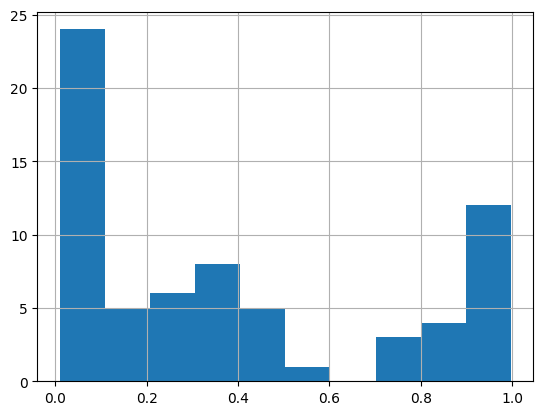

In [667]:
df2[df2['Draft_Prob'] >= 0.01]['Draft_Prob'].hist(bins=10)